# MAP5935 - Statistical Learning (Chapter 11 - Survival Analysis)

**Prof. Christian Jäkel**

https://www.statlearning.com/

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

from ISLP import load_data
from ISLP.models import ModelSpec as MS

from sklearn.linear_model import \
    (LinearRegression ,
    LogisticRegression ,
    Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline

from sklearn.model_selection import \
    (train_test_split ,
    GridSearchCV)

import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset

## *Conceptual Exercises*

### (8) Recall that the survival function $S(t)$, the hazard function $h(t)$, and the density function $f(t)$ are defined in equations $(1-3)$ below, respectively. Furthermore, define $F(t) = 1 − S(t)$.

###  Show that the following relationships hold:

$$ 
f(t)=dF(t)/dt
$$

$$ 
S(t)=\exp\Bigg(-\int_0^t h(u)du\Bigg)
$$

### Equation (1) 

$$ 
S(t)=\mathbb{P}(T>t)\tag{1}
$$

### Equation (2)
$$ 
h(t)=\lim_{\Delta t\to 0}\frac{\mathbb{P}(t<T\leq t+\Delta t | T > t)}{\Delta t}\tag{2}
$$

### Equation (3)
$$ 
f(t)=\lim_{\Delta t\to 0}\frac{\mathbb{P}(t<T\leq t+\Delta t)}{\Delta t}\tag{3}
$$

**Binary case: cross-entropy = negative log-likelihood**

Let $M=2$ classes, coded as $y_i\in\{0,1\}$ with
$$
y_{i1}=\mathbb 1\{y_i=1\}=y_i,\qquad
y_{i0}=\mathbb 1\{y_i=0\}=1-y_i .
$$
Model probabilities:
$$
f_1(x_i)=p(x_i)=\Pr(Y=1\mid x_i),\qquad
f_0(x_i)=1-p(x_i)=\Pr(Y=0\mid x_i).
$$

**Cross-entropy (multinomial negative log-likelihood) (1):**
$$
-\sum_{i=1}^n \sum_{m\in\{0,1\}} y_{im}\log f_m(x_i)
= -\sum_{i=1}^n \Big[ y_i\log p(x_i) + (1-y_i)\log \big(1-p(x_i)\big) \Big]. \tag{Cross-Entropy}
$$

**Bernoulli likelihood (2):**
$$
\ell(\beta_0,\beta_1)
=\prod_{i:y_i=1} p(x_i)\;\prod_{i':y_{i'}=0}\big(1-p(x_{i'})\big).
$$

Taking logs and writing as a single sum,
$$
\log \ell(\beta_0,\beta_1)
=\sum_{i=1}^n \Big[ y_i\log p(x_i) + (1-y_i)\log \big(1-p(x_i)\big) \Big].
$$
Hence the **negative** log-likelihood is
$$
-\log \ell(\beta_0,\beta_1)
= -\sum_{i=1}^n \Big[ y_i\log p(x_i) + (1-y_i)\log \big(1-p(x_i)\big) \Big]. \tag{Negative Log-Likelihood}
$$

Therefore, for $M=2$ the multinomial cross-entropy in (1) reduces exactly to the negative log of the Bernoulli likelihood in (2), i.e., the standard binary logistic regression loss.


## *Applied Exercises*

### (9) Fit a lag-$5$ autoregressive model to the NYSE data, as described in the text and Lab $10.9.6$. Refit the model with a $12$-level factor representing the month. Does this factor improve the performance of the model?

**Solution** - According with the LAB $10.9.6$, we need do adapt it for a lag-$12$ representing the month for an RNN.

The following code was provided in the LAB.


In [2]:
NYSE = load_data('NYSE')
NYSE.columns

Index(['day_of_week', 'DJ_return', 'log_volume', 'log_volatility', 'train'], dtype='object')

In [3]:
NYSE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6051 entries, 1962-12-03 to 1986-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   day_of_week     6051 non-null   category
 1   DJ_return       6051 non-null   float64 
 2   log_volume      6051 non-null   float64 
 3   log_volatility  6051 non-null   float64 
 4   train           6051 non-null   bool    
dtypes: bool(1), category(1), float64(3)
memory usage: 201.1+ KB


In [4]:
cols = ['DJ_return', 'log_volume', 'log_volatility']
X = pd.DataFrame(StandardScaler(
    with_mean=True ,
    with_std=True).fit_transform(NYSE[cols]),
                 columns=NYSE[cols].columns ,
                 index=NYSE.index)

In [5]:
for lag in range(1, 6):
    for col in cols:
        newcol = np.zeros(X.shape [0]) * np.nan
        newcol[lag:] = X[col].values[:-lag]
        X.insert(len(X.columns), "{0}_{1}".format(col , lag), newcol)
X.insert(len(X.columns), 'train', NYSE['train'])
X = X.dropna()

In [6]:
Y, train = X['log_volume'], X['train']
X = X.drop(columns=['train'] + cols)
X.columns

Index(['DJ_return_1', 'log_volume_1', 'log_volatility_1', 'DJ_return_2',
       'log_volume_2', 'log_volatility_2', 'DJ_return_3', 'log_volume_3',
       'log_volatility_3', 'DJ_return_4', 'log_volume_4', 'log_volatility_4',
       'DJ_return_5', 'log_volume_5', 'log_volatility_5'],
      dtype='object')

In [7]:
M = LinearRegression()
M.fit(X[train], Y[train])
M.score(X[~train], Y[~train])

0.41289129385625223

In [8]:
X_day = pd.merge(X, pd.get_dummies(NYSE['day_of_week']), on='date')

In [9]:
M.fit(X_day[train], Y[train])
M.score(X_day[~train], Y[~train])

0.4595563133053274

In [10]:
# As in LAB - Expect 5 lagged versions of each feature as indicated by the input_shape argument to the layer nn.RNN() below
ordered_cols = []
for lag in range(5,0,-1):
    for col in cols:
        ordered_cols.append('{0}_{1}'.format(col , lag))
X = X.reindex(columns=ordered_cols)
X.columns

Index(['DJ_return_5', 'log_volume_5', 'log_volatility_5', 'DJ_return_4',
       'log_volume_4', 'log_volatility_4', 'DJ_return_3', 'log_volume_3',
       'log_volatility_3', 'DJ_return_2', 'log_volume_2', 'log_volatility_2',
       'DJ_return_1', 'log_volume_1', 'log_volatility_1'],
      dtype='object')

In [11]:
# Reshape the Data
X_rnn = X.to_numpy().reshape((-1,5,3))
X_rnn.shape

(6046, 5, 3)

In [12]:
X_rnn

array([[[-0.54982334,  0.17507497, -4.35707786],
        [ 0.90519995,  1.51729071, -2.52905765],
        [ 0.43481275,  2.28378937, -2.41803694],
        [-0.43139673,  0.93517558, -2.36652094],
        [ 0.04634026,  0.22477858, -2.5009701 ]],

       [[ 0.90519995,  1.51729071, -2.52905765],
        [ 0.43481275,  2.28378937, -2.41803694],
        [-0.43139673,  0.93517558, -2.36652094],
        [ 0.04634026,  0.22477858, -2.5009701 ],
        [-1.30412619,  0.60591805, -1.366028  ]],

       [[ 0.43481275,  2.28378937, -2.41803694],
        [-0.43139673,  0.93517558, -2.36652094],
        [ 0.04634026,  0.22477858, -2.5009701 ],
        [-1.30412619,  0.60591805, -1.366028  ],
        [-0.00629379, -0.01366095, -1.50566722]],

       ...,

       [[ 0.96826597,  4.25840159,  0.26340567],
        [-0.18517843,  1.6026693 ,  0.12800392],
        [-0.75004612,  1.96484574,  0.08025041],
        [ 0.75120978, -0.97476289,  0.04688631],
        [ 0.19535153, -5.62381367, -0.08398311]],


Now we are ready to proceed with the *RNN*, which uses $12$ hidden units, and 10% dropout. After passing through the *RNN*, we extract the final time point as `val[:,-1]` in `forward()` below. This gets passed through a 10% dropout and then flattened through a linear layer

In [13]:
class NYSEModel(nn.Module):
    def __init__(self):
        super(NYSEModel , self).__init__()
        self.rnn = nn.RNN(3,
                          12,
                          batch_first=True)
        self.dense = nn.Linear(12, 1)
        self.dropout = nn.Dropout (0.1)
    def forward(self , x):
        val , h_n = self.rnn(x)
        val = self.dense(self.dropout(val[:,-1]))
        return torch.flatten(val)
nyse_model = NYSEModel()

**NYSE — RNN with 5 lags (Lab style) vs. 12 lags plus 12-factor representing the month for prediction purposes**

Below I will keep the exact **Lab 10.9.6** set-up (standardization, rolling lags, `RNN(input_size=15, hidden_size=12)` with RMSprop) and refit the model using **12 lags** instead of 5.


            Train RMSE  Test RMSE  Train MAE  Test MAE
Model                                                 
RNN (L=5)       0.6416     0.7884     0.4856    0.5774
RNN (L=12)      0.6300     0.7883     0.4790    0.5791


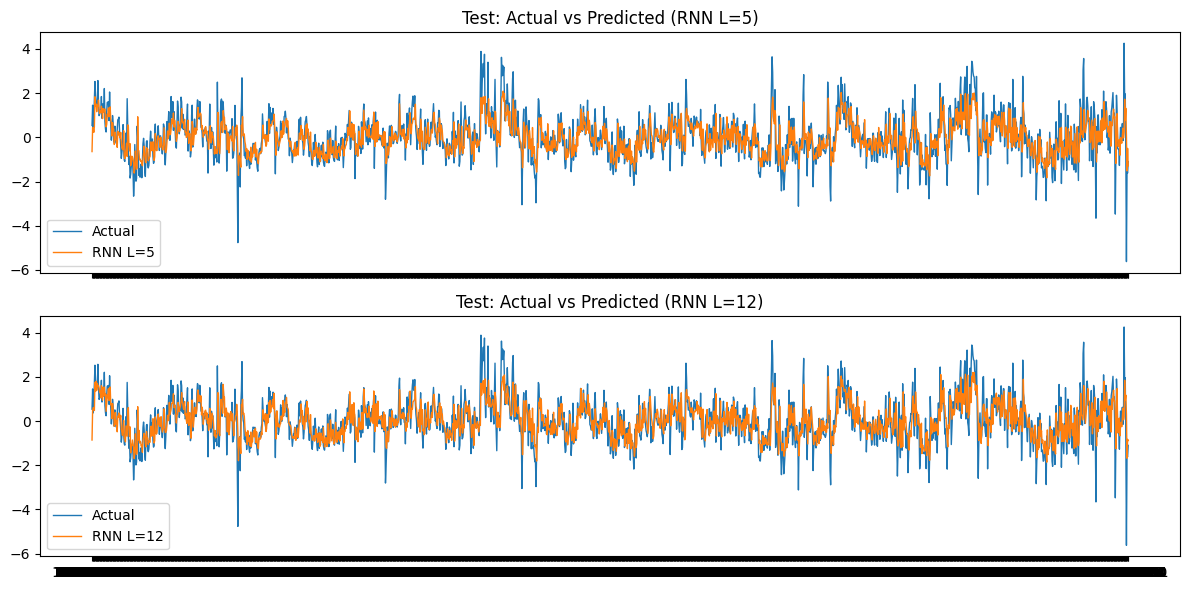

In [14]:
# =========================================================================
# RNN for NYSE: compare 5-lag vs 12-lag + 12-factor representing the month
# =========================================================================

from torch.utils.data import TensorDataset, DataLoader

# -----------------------------
# 0) Standardize Data
# -----------------------------


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

scaler = StandardScaler(with_mean=True, with_std=True)
X_std = pd.DataFrame(
    scaler.fit_transform(NYSE[cols]),
    columns=cols,
    index=NYSE.index
)

# -----------------------------
# Helpers
# -----------------------------
def make_lag_matrix(L: int):
    """Return (X_lagged, y, train_mask) for a given number of lags L,
    following the Lab's construction (no leakage)."""
    X = X_std.copy()
    
    # Lag columns (1..L) for each of the 3 standardized series
    for lag in range(1, L+1):
        for c in cols:
            newcol = np.full(len(X), np.nan)
            newcol[lag:] = X[c].values[:-lag]
            X.insert(len(X.columns), f"{c}_{lag}", newcol)
            
    # add train flag and drop rows with NA lags
    X['train'] = NYSE['train']
    X = X.dropna().copy()

    # target: current standardized log_volume
    y = X['log_volume'].copy()
    train_mask = X['train'].astype(bool).values

    # keep only lag columns and order as in the Lab
    ordered = []
    for lag in range(L, 0, -1):   # newest last so RNN last step is most recent
        for c in cols:
            ordered.append(f"{c}_{lag}")
    X_lag = X.reindex(columns=ordered).copy()
    return X_lag, y, train_mask

# 4) Input_size = 15
class NYSEModelWithMonth(nn.Module):
    def __init__(self, input_size=15, hidden_size=12):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.1)
        self.dense = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        return torch.flatten(self.dense(out))


def to_loader(X_seq, y, mask, batch_size=64):
    """Make PyTorch DataLoaders for train/test."""
    X_train = torch.tensor(X_seq[mask], dtype=torch.float32)
    y_train = torch.tensor(y[mask].values, dtype=torch.float32)
    X_test  = torch.tensor(X_seq[~mask], dtype=torch.float32)
    y_test  = torch.tensor(y[~mask].values, dtype=torch.float32)
    train_dl = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_dl  = DataLoader(TensorDataset(X_test,  y_test ), batch_size=batch_size, shuffle=False)
    return train_dl, test_dl, y[~mask].index  # keep test index for plotting

def train_rnn(train_dl, model, epochs=40, lr=1e-3, device='cpu'):
    model.to(device)
    crit = nn.MSELoss()
    opt = RMSprop(model.parameters(), lr=lr)
    model.train()
    for ep in range(epochs):
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = crit(pred, yb)
            loss.backward()
            opt.step()
    return model

@torch.no_grad()
def evaluate_rnn(dataloader, model, device='cpu'):
    model.eval()
    preds, trues = [], []
    for xb, yb in dataloader:
        xb = xb.to(device)
        preds.append(model(xb).cpu().numpy())
        trues.append(yb.numpy())
    y_hat = np.concatenate(preds)
    y_true = np.concatenate(trues)
    rmse = np.sqrt(np.mean((y_true - y_hat)**2))
    mae  = np.mean(np.abs(y_true - y_hat))
    return rmse, mae, y_true, y_hat


def run_experiment(L, epochs=40, lr=1e-3, device='cpu'):
    # 1) lagged design -> reshape to (n, L, 3)
    X_lag, y, train_mask = make_lag_matrix(L)
    X_seq = X_lag.to_numpy().reshape((-1, L, 3))

    # Month extraction---
    months_series = pd.DatetimeIndex(X_lag.index).month 
    months = pd.get_dummies(months_series, prefix='m')       
    months = months.reindex(columns=[f"m_{i}" for i in range(1, 13)], fill_value=0)
    M = months.to_numpy()[:, None, :]                        # (n, 1, 12)
    M = np.repeat(M, L, axis=1)                              # (n, L, 12) replicate across steps

    # 1.3) Concatenate: (DJ_return, log_volume, log_volatility, month_1..month_12)
    X_seq_aug = np.concatenate([X_seq, M], axis=2)           # (n, L, 15)

    # 2) loaders (use augmented inputs)
    train_dl, test_dl, test_idx = to_loader(X_seq_aug, y, train_mask, batch_size=64)

    # --- FIX 2: use the 15-input model ---
    model = NYSEModelWithMonth(input_size=15, hidden_size=12)

    # 3) train, eval
    model = train_rnn(train_dl, model, epochs=epochs, lr=lr, device=device)
    tr_rmse, tr_mae, _, _ = evaluate_rnn(train_dl, model, device=device)
    te_rmse, te_mae, y_true, y_hat = evaluate_rnn(test_dl,  model, device=device)

    return {
        "L": L,
        "model": model,
        "train_RMSE": tr_rmse,
        "train_MAE": tr_mae,
        "test_RMSE": te_rmse,
        "test_MAE": te_mae,
        "test_index": test_idx,
        "y_true_test": y_true,
        "y_hat_test": y_hat
    }


# -----------------------------
# 1) Train 5-lag (Lab default) and 12-lag models
# -----------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
res_5  = run_experiment(L=5,  epochs=50, lr=1e-3, device=device)
res_12 = run_experiment(L=12, epochs=50, lr=1e-3, device=device)

print(pd.DataFrame([
    {"Model": "RNN (L=5)",  "Train RMSE": res_5["train_RMSE"],  "Test RMSE": res_5["test_RMSE"],
     "Train MAE": res_5["train_MAE"],  "Test MAE": res_5["test_MAE"]},
    {"Model": "RNN (L=12)", "Train RMSE": res_12["train_RMSE"], "Test RMSE": res_12["test_RMSE"],
     "Train MAE": res_12["train_MAE"], "Test MAE": res_12["test_MAE"]}
]).set_index("Model").round(4))

# -----------------------------
# 2) Plot test predictions
# -----------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(res_5["test_index"], res_5["y_true_test"], label="Actual", lw=1)
ax[0].plot(res_5["test_index"], res_5["y_hat_test"], label="RNN L=5", lw=1)
ax[0].set_title("Test: Actual vs Predicted (RNN L=5)")
ax[0].legend()

ax[1].plot(res_12["test_index"], res_12["y_true_test"], label="Actual", lw=1)
ax[1].plot(res_12["test_index"], res_12["y_hat_test"], label="RNN L=12", lw=1)
ax[1].set_title("Test: Actual vs Predicted (RNN L=12)")
ax[1].legend()

plt.tight_layout()
plt.show()


**Comments**

- **Month feature + L=5 vs L=12:**  
  Test errors are almost unchanged. Your run shows  
  **L=5:** RMSE **0.7884**, MAE **0.5774**  
  **L=12:** RMSE **0.7883**, MAE **0.5791**  
  → a **very small (~0.3%) improvement** with the longer daily window; practically negligible.

- **Seasonality signal appears weak.**  
  Adding the **month** indicator (replicated across the sequence) does **not** materially improve out-of-sample fit.

- **Conclusion:**  
  With this Lab setup, **including month and extending lags from 5→12 does not meaningfully change performance**. The 5-day window already captures most of the predictive component.